In [1]:
from google.colab import drive
import pandas as pd

# Step 1: Mount Drive
drive.mount('/content/drive')

# Step 2: Load the Excel file
file_path = '/content/drive/My Drive/Team A Exported Data/Navy Revenue Report FY20-FY24_1/Navy Revenue Report FY20-FY24-1 Format 1.xlsx'
df = pd.read_excel(file_path)

# Step 3: Preview data
df.head()


Mounted at /content/drive


,Country,Installation,FY16,FY17,FY18,FY19,FY20 thru SEP,ANNUALIZED FY20
0,Korea,Chin Hae,180813.56,107702.89,186026.95,178352.1,357443.06,357443.06
1,Malaysia,Singapore,21449.75,209637.55,222577,306888,33112.95,33112.95
2,Japan,Okinawa,482923.16,409981.09,380989.25,395305.7,280698.3,280698.3
3,Japan,New Sanno Hotel,927183.13,866641.41,888156.3,902217.9,651836.1,651836.1
4,Japan,Atsugi,1178216.09,1286398.7,1139178.4,1364078.3,1083616.25,1083616.25


# Task
Perform EDA on the dataframe `df`.

## Understand the data

### Subtask:
Display the first few rows, the data types of each column, and summary statistics for numerical columns in `df`.


**Reasoning**:
Display the first few rows, data types, and summary statistics of the dataframe as requested.



In [2]:
display(df.head())
display(df.info())
display(df.describe())

,Country,Installation,FY16,FY17,FY18,FY19,FY20 thru SEP,ANNUALIZED FY20
0,Korea,Chin Hae,180813.56,107702.89,186026.95,178352.1,357443.06,357443.06
1,Malaysia,Singapore,21449.75,209637.55,222577,306888,33112.95,33112.95
2,Japan,Okinawa,482923.16,409981.09,380989.25,395305.7,280698.3,280698.3
3,Japan,New Sanno Hotel,927183.13,866641.41,888156.3,902217.9,651836.1,651836.1
4,Japan,Atsugi,1178216.09,1286398.7,1139178.4,1364078.3,1083616.25,1083616.25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Country          82 non-null     object
 1   Installation     73 non-null     object
 2   FY16             76 non-null     object
 3   FY17             75 non-null     object
 4   FY18             76 non-null     object
 5   FY19             76 non-null     object
 6   FY20 thru SEP    76 non-null     object
 7   ANNUALIZED FY20  76 non-null     object
dtypes: object(8)
memory usage: 5.3+ KB


None

,Country,Installation,FY16,FY17,FY18,FY19,FY20 thru SEP,ANNUALIZED FY20
count,82,73,76,75,76,76,76,76
unique,13,13,73,73,73,70,70,71
top,Japan,Chin Hae,-,FY18,-,-,-,-
freq,30,6,2,2,2,5,5,3


## Check for missing values

### Subtask:
Identify any missing values in `df` and visualize their distribution.


**Reasoning**:
Calculate and print the count and percentage of missing values for each column, and then visualize the distribution of missing values using a heatmap.



Missing Values Count:
Country             1
Installation       10
FY16                7
FY17                8
FY18                7
FY19                7
FY20 thru SEP       7
ANNUALIZED FY20     7
dtype: int64

Missing Values Percentage:
Country             1.204819
Installation       12.048193
FY16                8.433735
FY17                9.638554
FY18                8.433735
FY19                8.433735
FY20 thru SEP       8.433735
ANNUALIZED FY20     8.433735
dtype: float64


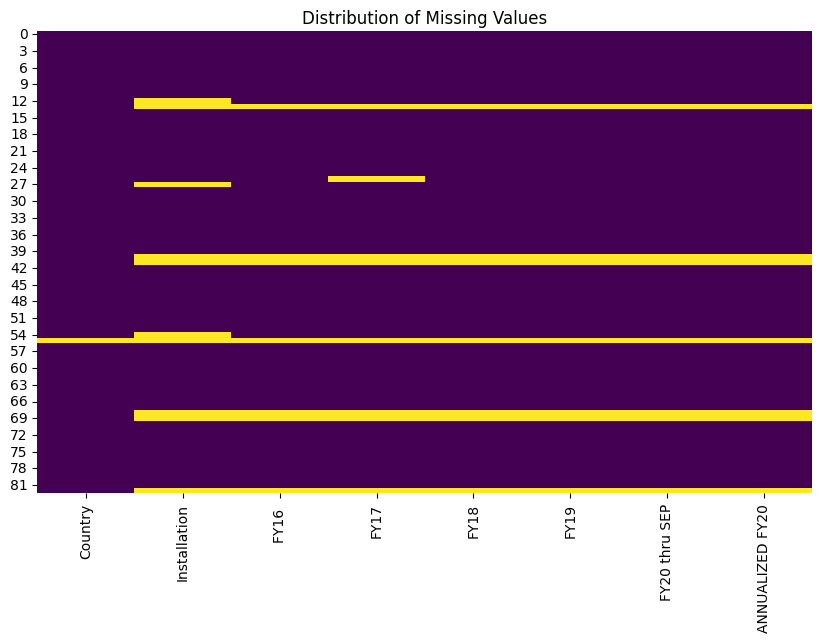

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of missing values for each column
missing_values_count = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_values_percentage = (missing_values_count / len(df)) * 100

# Print the count and percentage of missing values
print("Missing Values Count:")
print(missing_values_count)
print("\nMissing Values Percentage:")
print(missing_values_percentage)

# Visualize the distribution of missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Distribution of Missing Values')
plt.show()

## Analyze distributions

### Subtask:
Plot histograms or other appropriate visualizations for numerical and categorical columns in `df` to understand their distributions.


**Reasoning**:
Convert the fiscal year columns to numeric, handle the '-' values, and then plot histograms for the numerical columns and bar plots for the categorical columns.



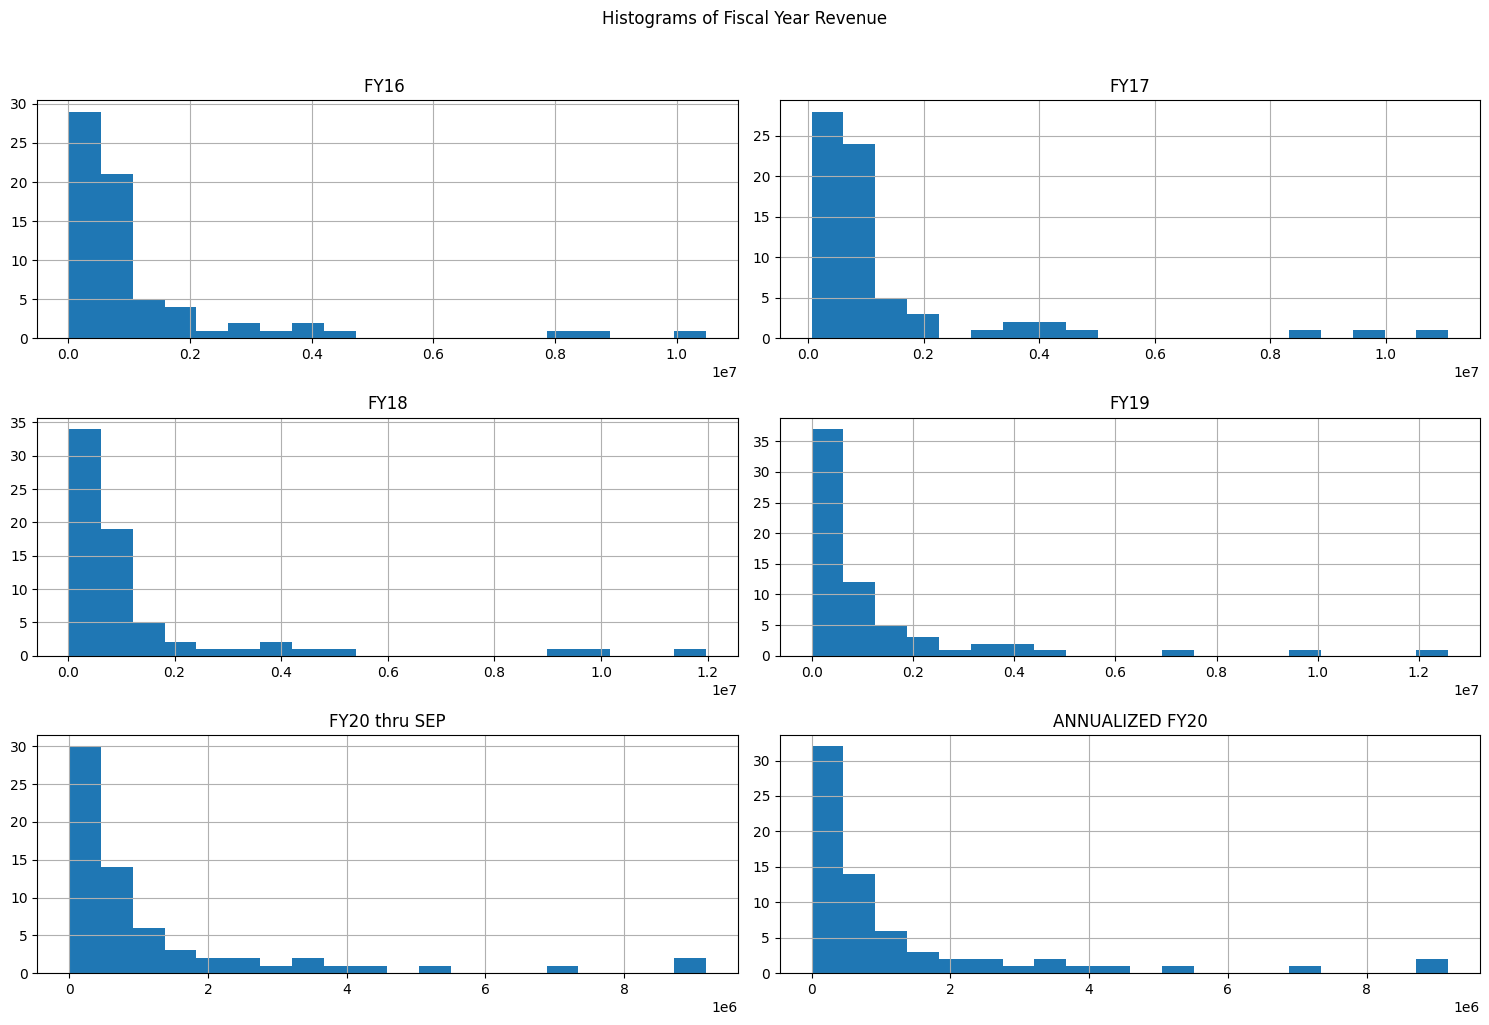

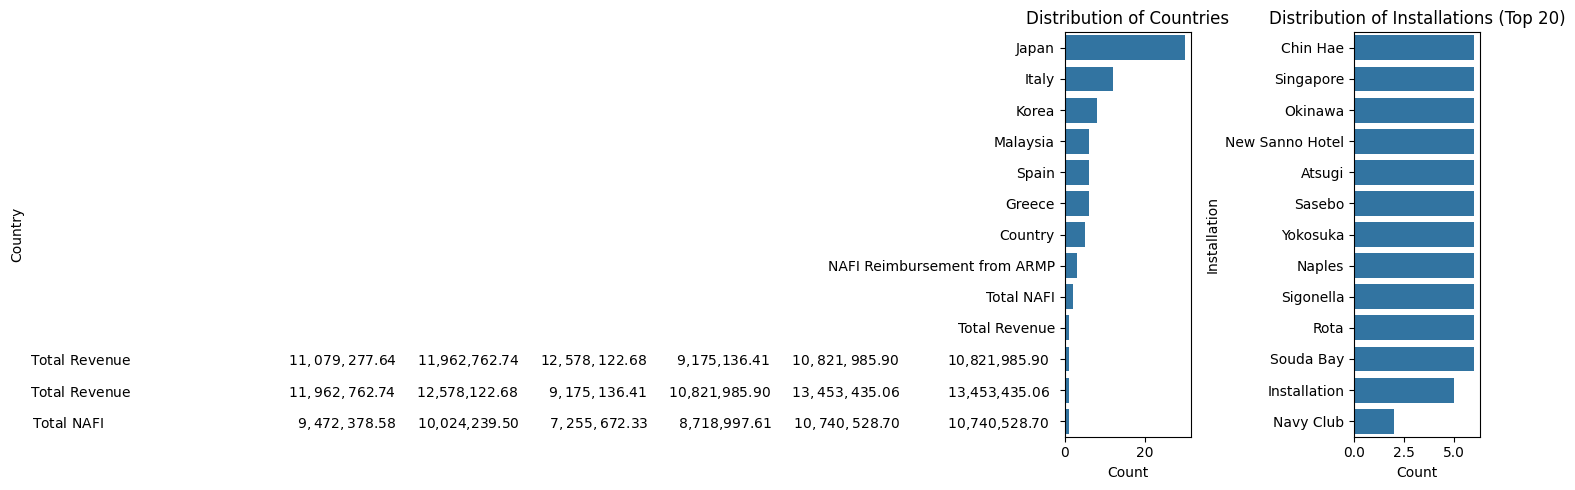

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify fiscal year columns
fiscal_year_cols = ['FY16\xa0', 'FY17', 'FY18', 'FY19', 'FY20\xa0thru\xa0SEP', 'ANNUALIZED\xa0FY20']

# Replace '-' with NaN and convert to numeric
for col in fiscal_year_cols:
    #df[col] = df[col].replace('-', np.nan).astype(float)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Plot histograms for numerical columns
df[fiscal_year_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle('Histograms of Fiscal Year Revenue', y=1.02)
plt.tight_layout()
plt.show()

# Plot bar plots for categorical columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().index)
plt.title('Distribution of Countries')
plt.xlabel('Count')
plt.ylabel('Country')

plt.subplot(1, 2, 2)
# Handle missing values in 'Installation' by dropping them for plotting purposes
df_installation = df.dropna(subset=['Installation'])
sns.countplot(data=df_installation, y='Installation', order=df_installation['Installation'].value_counts().index[:20]) # Displaying top 20 for readability
plt.title('Distribution of Installations (Top 20)')
plt.xlabel('Count')
plt.ylabel('Installation')

plt.tight_layout()
plt.show()

**Reasoning**:
The error indicates that there are still non-numeric values in the 'FY16\xa0' column after replacing '-'. Inspect the unique values in this column to identify what other non-numeric entries exist and need to be handled before converting to float.



In [5]:
print(df['FY16\xa0'].unique())

[  180813.56    21449.75   482923.16   927183.13  1178216.09  1997906.83
  3103960.35   991376.15   460034.89  1016488.63   114909.17         nan
 10475261.71   123795.8     15014.8    387932.9    741316.35   935369.
  1604898.75  2655260.45   699187.7    321951.05   711764.65    80447.65
  8276939.1    107702.89   209637.55   409981.09   866641.41  1286398.7
  1778821.45  3892849.94  1116789.71   401614.4    889430.76   119409.74
    74906.95   146746.35   326327.1    696355.3   1026505.95  1427681.65
  3310376.25   768914.15   280598.35   622481.7     83261.65  8764155.4
   186026.95   222577.     380989.25   888156.3   1139178.4   2139203.34
  4319686.    1010641.2    633632.05   889084.8    153587.45   130218.85
   155803.95   302532.15   703721.6    909859.05  1712121.55  3676224.15
   705632.4    446035.73   622717.95   107511.2 ]


**Reasoning**:
The unique values show that besides numeric values and '-', there are also strings like 'FY16\xa0', 'FY17', and 'FY18' which are headers or other non-data entries. Need to filter out these rows before converting to numeric.



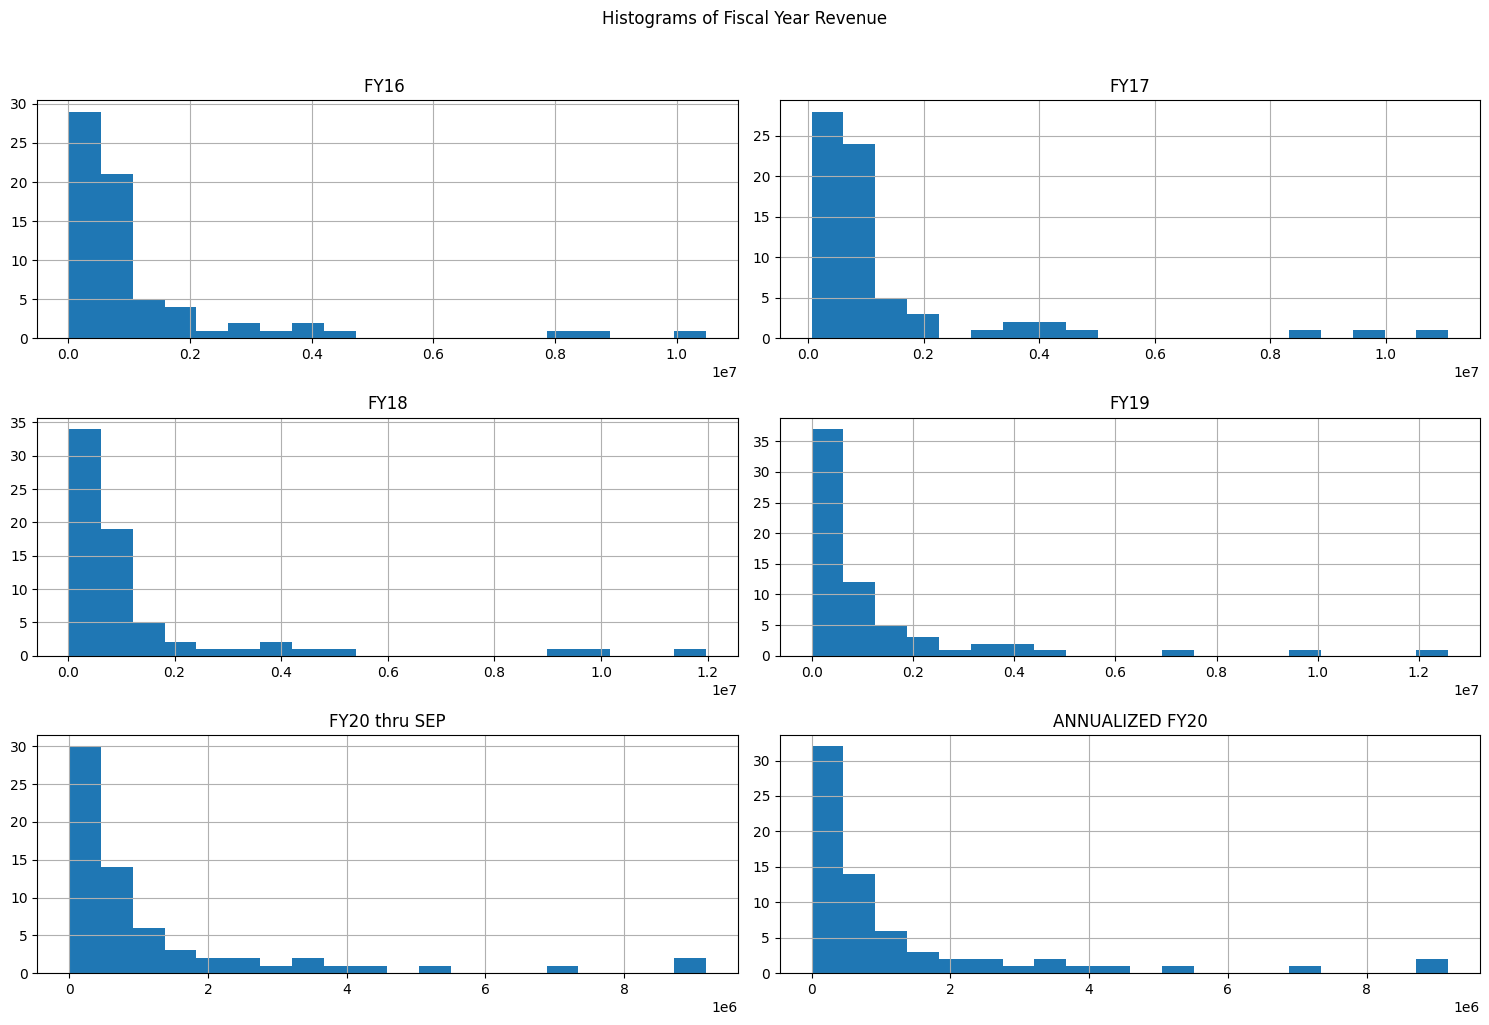

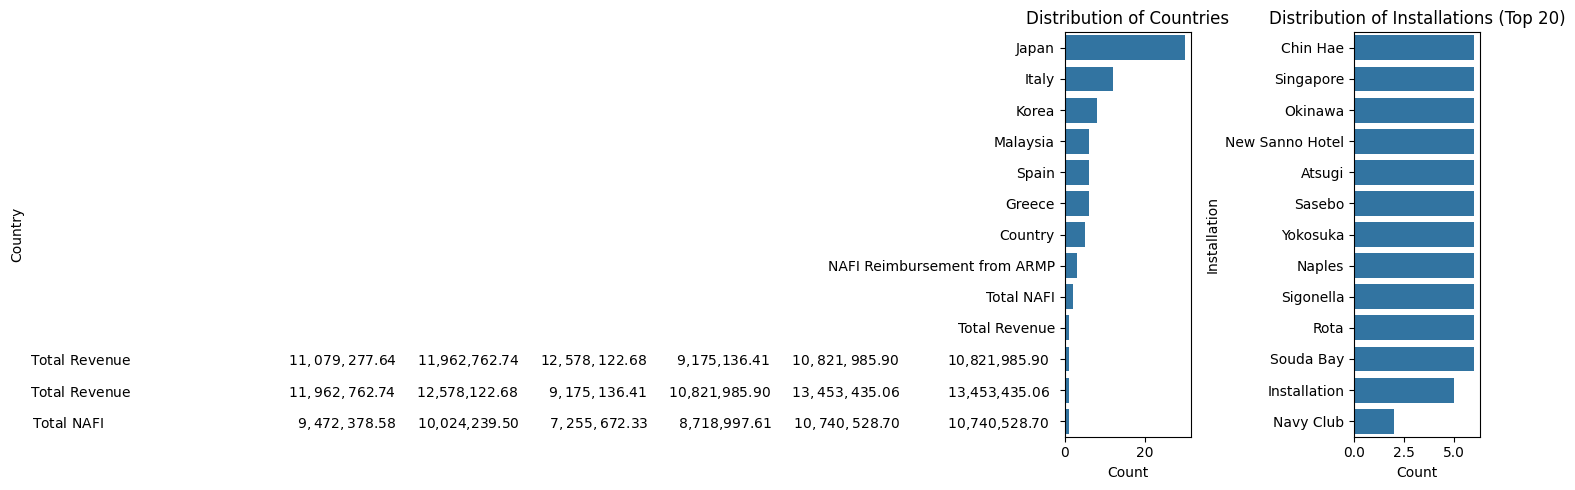

In [6]:
# Identify fiscal year columns
fiscal_year_cols = ['FY16\xa0', 'FY17', 'FY18', 'FY19', 'FY20\xa0thru\xa0SEP', 'ANNUALIZED\xa0FY20']

# Filter out rows where any of the fiscal year columns contain non-numeric strings
for col in fiscal_year_cols:
    df = df[df[col].apply(lambda x: isinstance(x, (int, float)) or str(x).replace('.', '', 1).isdigit() or x == '-')]

# Replace '-' with NaN and convert to numeric
for col in fiscal_year_cols:
    df[col] = df[col].replace('-', np.nan).astype(float)

# Plot histograms for numerical columns
df[fiscal_year_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle('Histograms of Fiscal Year Revenue', y=1.02)
plt.tight_layout()
plt.show()

# Plot bar plots for categorical columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().index)
plt.title('Distribution of Countries')
plt.xlabel('Count')
plt.ylabel('Country')

plt.subplot(1, 2, 2)
# Handle missing values in 'Installation' by dropping them for plotting purposes
df_installation = df.dropna(subset=['Installation'])
sns.countplot(data=df_installation, y='Installation', order=df_installation['Installation'].value_counts().index[:20]) # Displaying top 20 for readability
plt.title('Distribution of Installations (Top 20)')
plt.xlabel('Count')
plt.ylabel('Installation')

plt.tight_layout()
plt.show()

## Explore relationships

### Subtask:
Investigate relationships between columns in `df` using scatter plots, correlation matrices, or other relevant visualizations.


**Reasoning**:
Calculate and visualize the correlation matrix for the fiscal year columns using a heatmap.



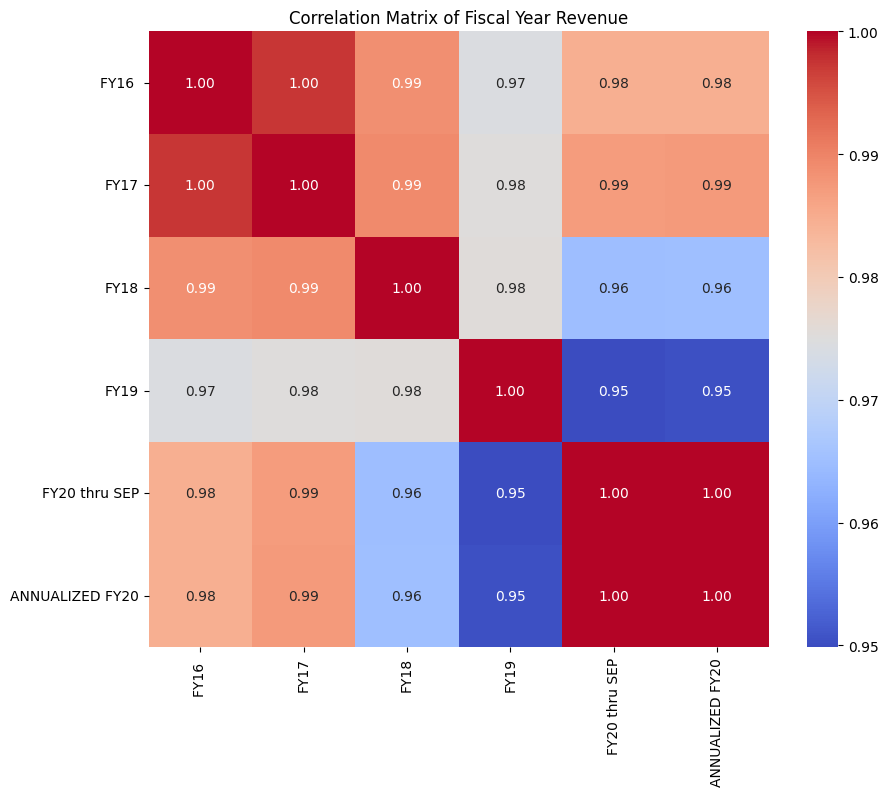

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns (fiscal year columns)
fiscal_year_cols = ['FY16\xa0', 'FY17', 'FY18', 'FY19', 'FY20\xa0thru\xa0SEP', 'ANNUALIZED\xa0FY20']
df_numerical = df[fiscal_year_cols]

# Calculate the correlation matrix
correlation_matrix = df_numerical.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Fiscal Year Revenue')
plt.show()

**Reasoning**:
Create scatter plots for selected pairs of fiscal year columns to visualize their relationships based on the correlation matrix.



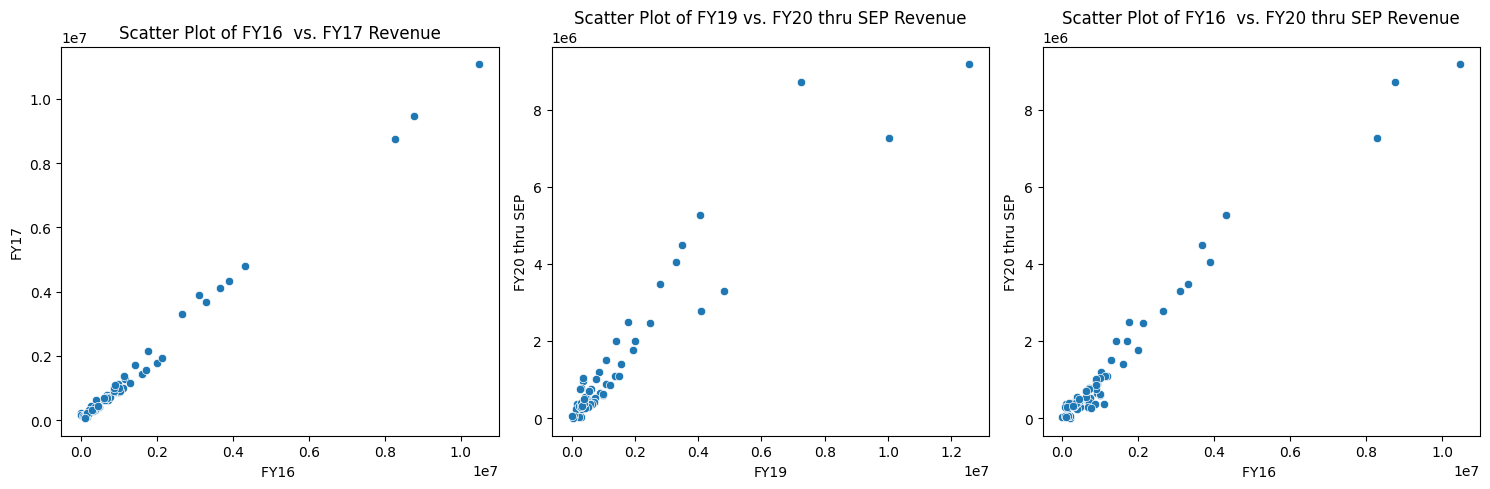

In [8]:
# Create scatter plots for selected pairs of fiscal year columns
selected_pairs = [('FY16\xa0', 'FY17'), ('FY19', 'FY20\xa0thru\xa0SEP'), ('FY16\xa0', 'FY20\xa0thru\xa0SEP')]

plt.figure(figsize=(15, 5))

for i, (col1, col2) in enumerate(selected_pairs):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f'Scatter Plot of {col1} vs. {col2} Revenue')
    plt.xlabel(col1)
    plt.ylabel(col2)

plt.tight_layout()
plt.show()

## Identify outliers

### Subtask:
Detect and visualize potential outliers in the numerical columns of `df`.


**Reasoning**:
Create box plots for each of the selected fiscal year columns to visualize potential outliers.



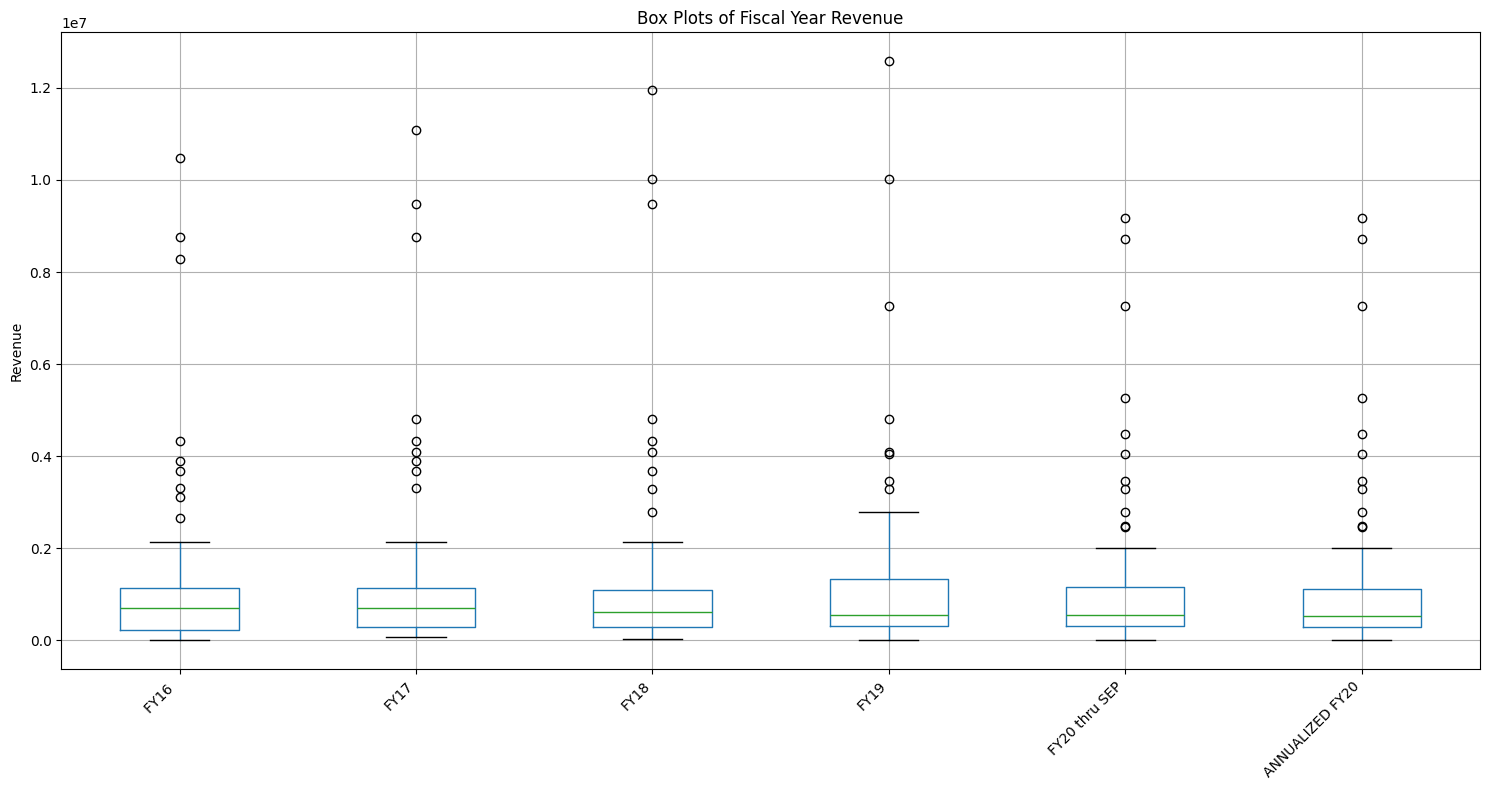

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the fiscal year revenue columns
fiscal_year_cols = ['FY16\xa0', 'FY17', 'FY18', 'FY19', 'FY20\xa0thru\xa0SEP', 'ANNUALIZED\xa0FY20']

# Create box plots for each fiscal year column
plt.figure(figsize=(15, 8))
df[fiscal_year_cols].boxplot()
plt.title('Box Plots of Fiscal Year Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   All columns in the initial dataframe were of the `object` data type, requiring conversion for numerical analysis.
*   Missing values were present in several columns: 'Installation' had the highest percentage (12.05%), followed by the fiscal year columns (8.43% to 9.64%), and 'Country' had the fewest (1.20%).
*   The fiscal year columns contained non-numeric characters ('-' and specific strings like 'FY16 ') which needed handling before conversion to a numerical format.
*   After cleaning and converting, the distribution of fiscal year revenues showed varying patterns across the years, with potential outliers indicated in the box plots.
*   Strong positive correlations were observed between consecutive fiscal year revenue figures, as shown by the correlation matrix and scatter plots.

### Insights or Next Steps

*   Proceed with data cleaning by addressing missing values (e.g., imputation or removal) and confirming the numerical conversion of the fiscal year columns to enable further quantitative analysis.
*   Investigate the nature and impact of the identified outliers in the fiscal year revenue data, and decide on appropriate handling strategies (e.g., removal or transformation) based on the analysis objectives.
